In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('diabetes.csv')

* pregnant - Number of times pregnant,
* glucose - Plasma glucose concentration a 2 hours in an oral glucose tolerance test
* bp - Diastolic blood pressure (mm Hg)
* skin - Triceps skin fold thickness (mm)
* insulin - 2-Hour serum insulin (mu U/ml)
* bmi - Body mass index
* pedigree - Diabetes pedigree function
* label - 1 means diabetes patient

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Podział na zmienną zależną i zmienne niezależne

In [5]:
X = df.drop(columns='Outcome')
y = df['Outcome']

## Podział na zbiory: treningowy i testowy

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Trenowanie drzewa klasyfikującego
Dla max_depth>5 trudno wizualnie zinterpretować wynik

In [7]:
from sklearn import tree

clftree = tree.DecisionTreeClassifier()#max_depth=3, min_samples_leaf=20)
clftree.fit(X_train, y_train)

DecisionTreeClassifier()

Przewidywanie wartości przy użyciu modelu

In [8]:
y_train_pred = clftree.predict(X_train)
y_test_pred = clftree.predict(X_test)

## Ocena modelu

TP = True positive; FP = False positive; TN = True negative; FN = False negative

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix

confusion matrix = 

[TN,  FP]

[FN,  TP]

In [10]:
confusion_matrix(y_train,y_train_pred)

array([[393,   0],
       [  0, 221]], dtype=int64)

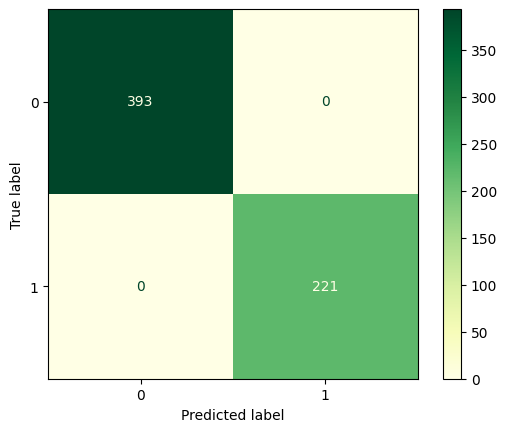

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# parametr normalize jest ze zbioru {'true', 'pred', 'all', None} domyślnie = None
ConfusionMatrixDisplay.from_estimator(clftree, X_train, y_train, cmap='YlGn')#, normalize = 'true')
plt.show()

In [12]:
confusion_matrix(y_test,y_test_pred)

array([[88, 19],
       [14, 33]], dtype=int64)

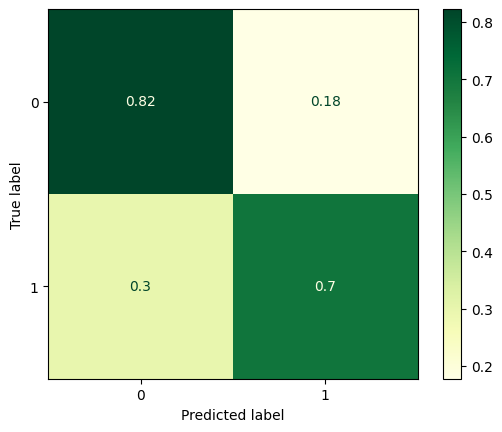

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# parametr normalize jest ze zbioru {'true', 'pred', 'all', None} domyślnie = None
ConfusionMatrixDisplay.from_estimator(clftree, X_test, y_test, cmap='YlGn', normalize = 'true')
plt.show()

Accuracy = (TP + TN)/(TP + TN + FP + FN)

In [14]:
accuracy_score(y_test,y_test_pred)

0.7857142857142857

### Rysowanie drzewa decyzyjnego

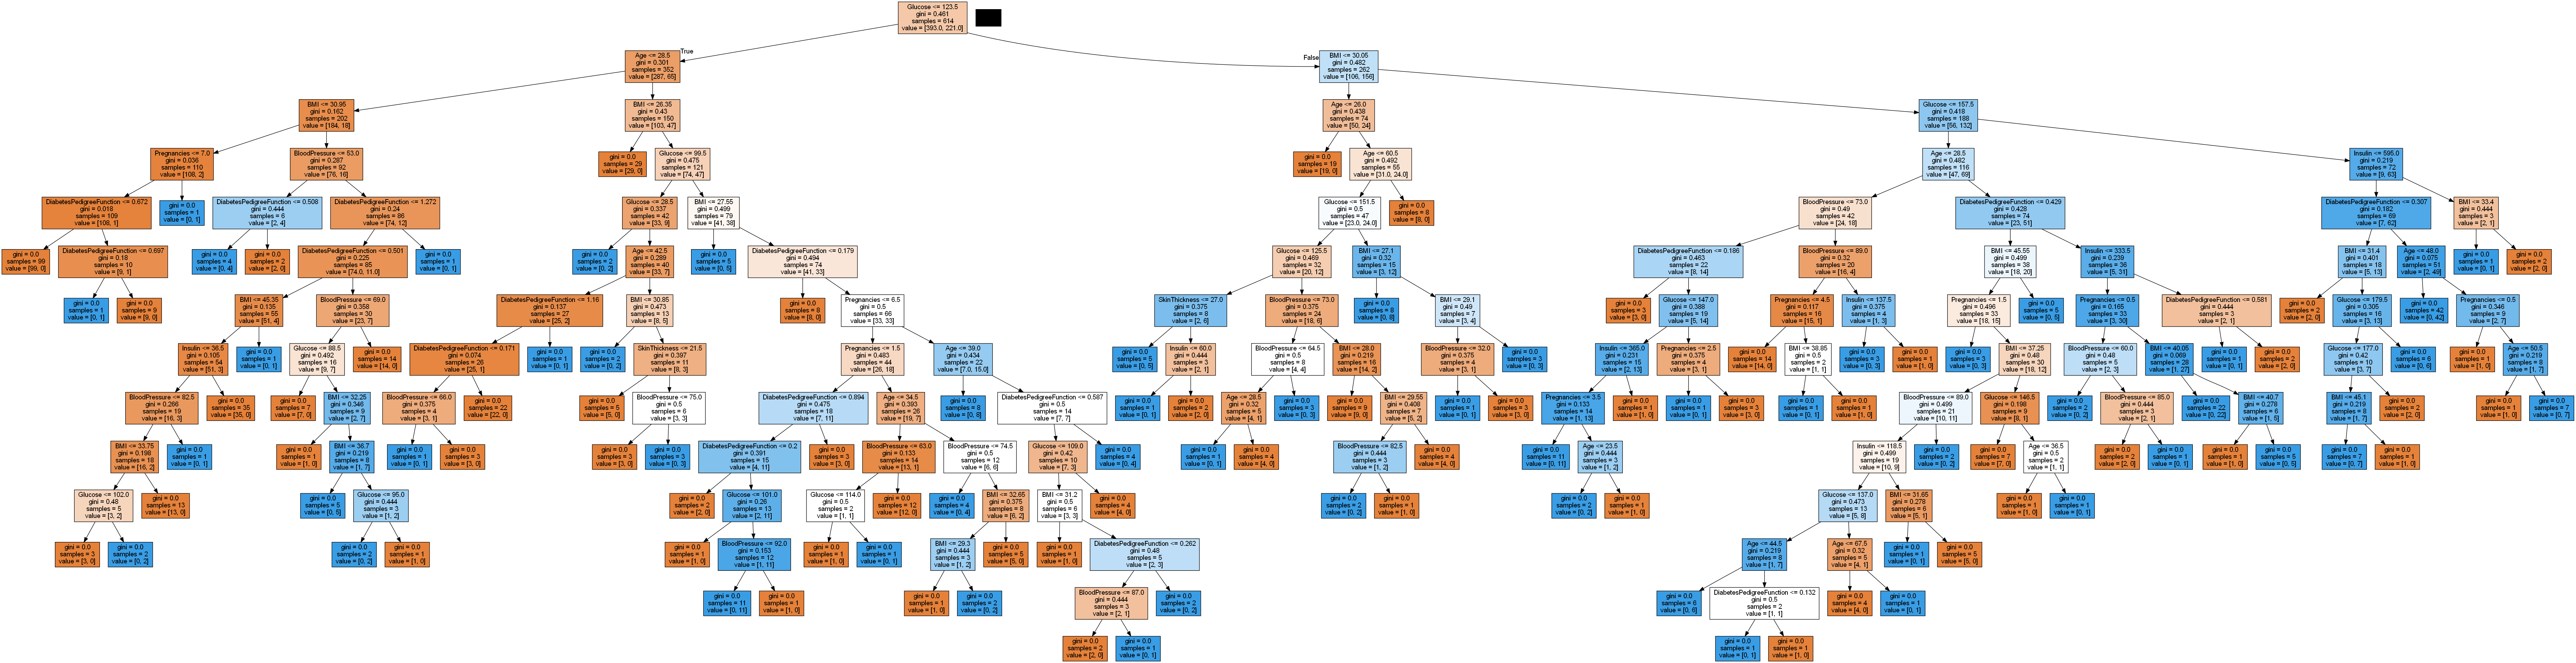

In [15]:
dot_data = tree.export_graphviz(clftree, feature_names=X_train.columns, out_file=None, filled=True)
from IPython.display import Image
import pydotplus
import graphviz
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

### Parametry kontrolujące rozmiar drzewa

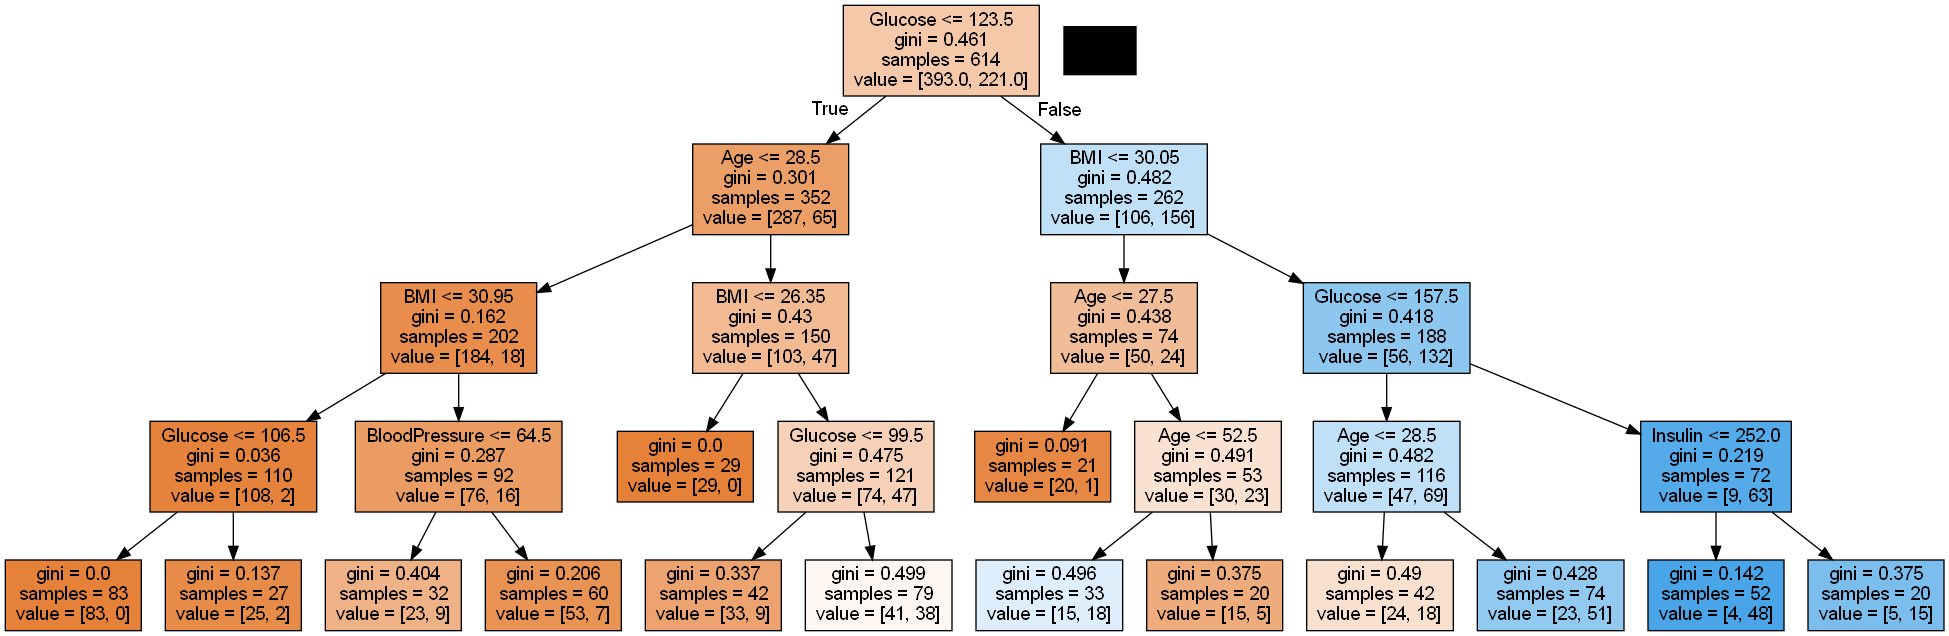

In [16]:
clftree2 = tree.DecisionTreeClassifier(min_samples_leaf=20, max_depth=4)
clftree2.fit(X_train, y_train)
dot_data = tree.export_graphviz(clftree2, feature_names=X_train.columns, out_file=None, filled=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())


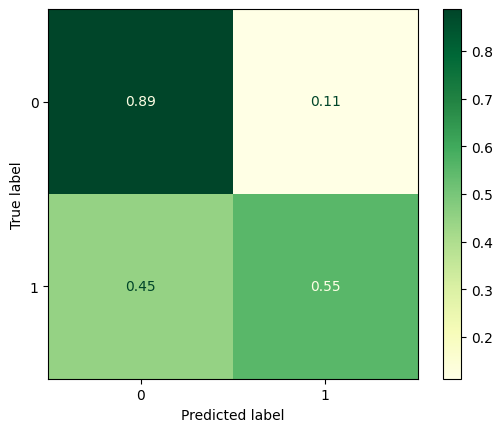

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# parametr normalize jest ze zbioru {'true', 'pred', 'all', None} domyślnie = None
ConfusionMatrixDisplay.from_estimator(clftree2, X_test, y_test, cmap='YlGn', normalize = 'true')
plt.show()

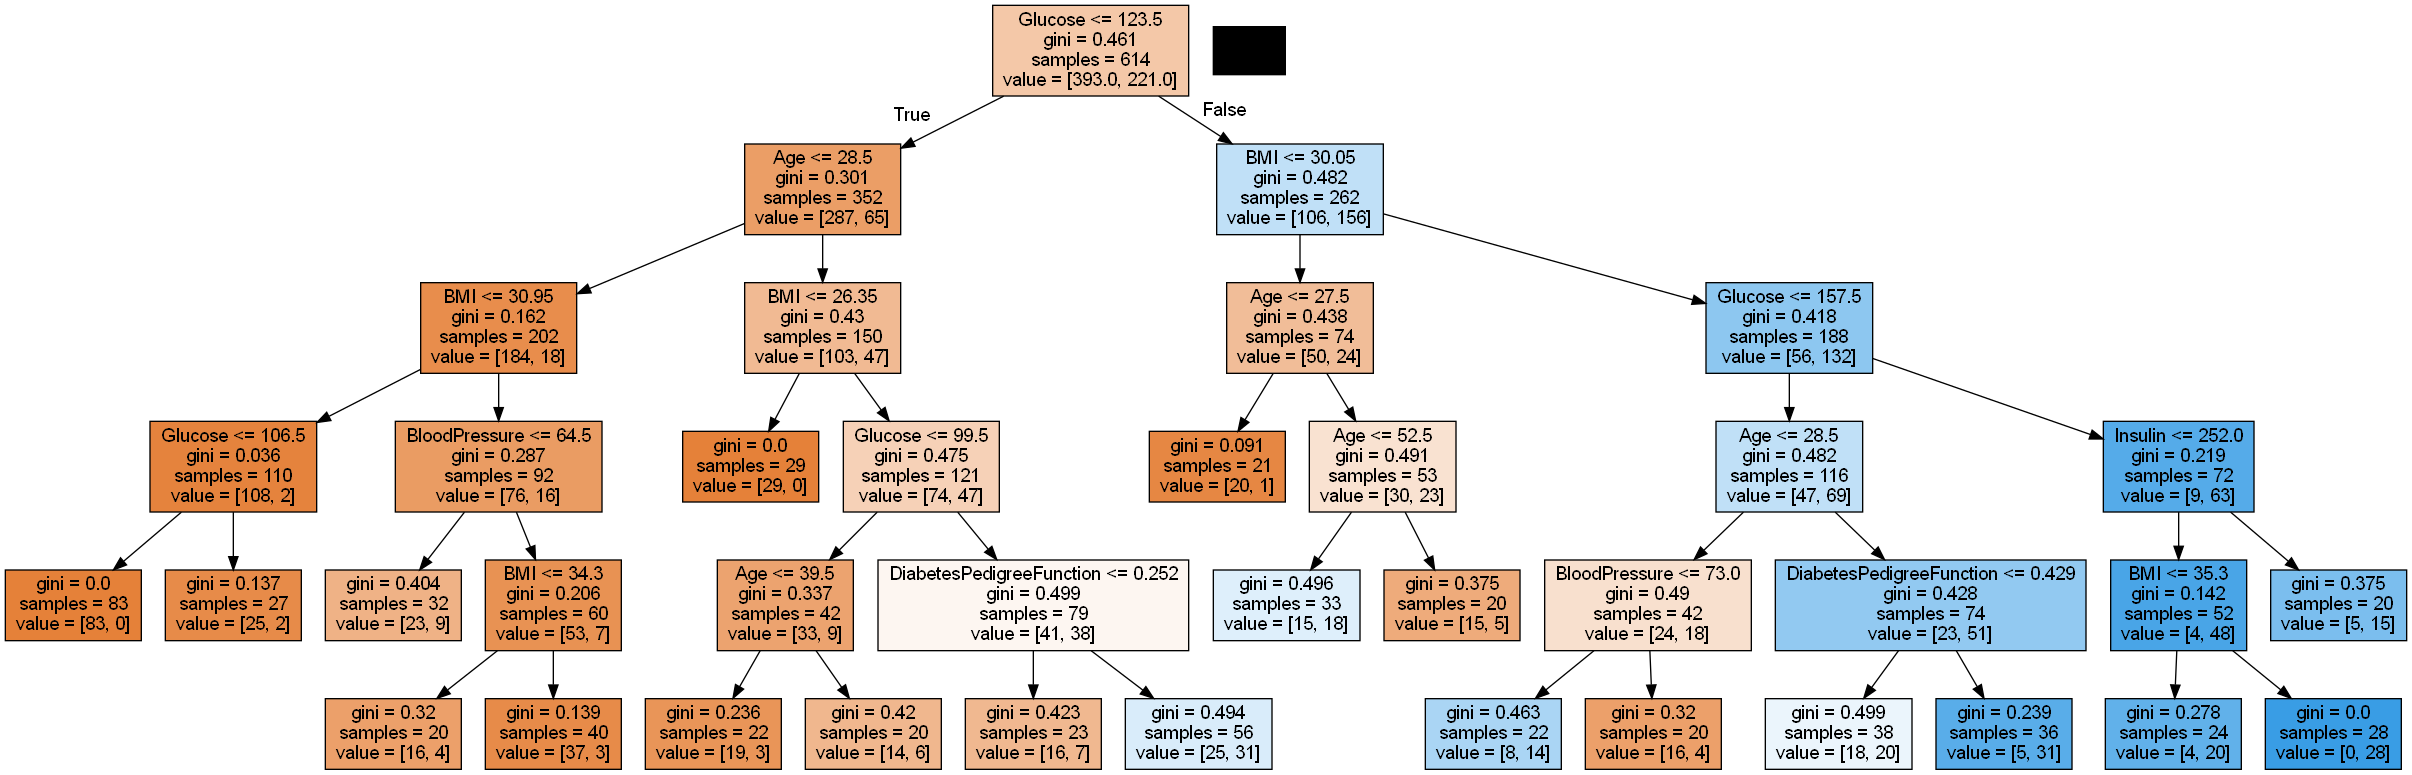

In [18]:
clftree3 = tree.DecisionTreeClassifier(min_samples_leaf=20, max_depth=5)
# clftree3 = tree.DecisionTreeClassifier() 
clftree3.fit(X_train, y_train)
dot_data = tree.export_graphviz(clftree3, feature_names=X_train.columns, out_file=None, filled=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

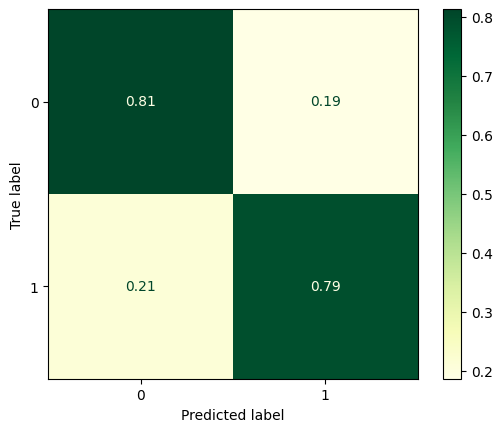

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# parametr normalize jest ze zbioru {'true', 'pred', 'all', None} domyślnie = None
ConfusionMatrixDisplay.from_estimator(clftree3, X_test, y_test, cmap='YlGn', normalize = 'true')
plt.show()

## Parametry drzewa 

Idziemy do strony i omawiamy kilka podstawowych parametrów

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [20]:
from sklearn.model_selection import GridSearchCV

classtree = tree.DecisionTreeClassifier()

param_grid = {'criterion':['gini', 'entropy', 'log_loss'],
    'max_depth': [2,3,4,5,6,7,8,None], 
              'min_samples_leaf': range(5,20)
              }
classtree_gscv = GridSearchCV(classtree, param_grid, cv=5)
classtree_gscv.fit(X, y)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 3, 4, 5, 6, 7, 8, None],
                         'min_samples_leaf': range(5, 20)})

In [21]:
3*8*15*5

1800

In [22]:
classtree_gscv.best_params_

{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 18}

In [23]:
classtree_gscv.best_score_

0.7488158899923606

In [24]:
clftree4 = tree.DecisionTreeClassifier(max_depth= 7, min_samples_leaf=18)
clftree4.fit(X,y)

DecisionTreeClassifier(max_depth=7, min_samples_leaf=18)

## Wpływ zmiennych niezależnych na zmienną zależną

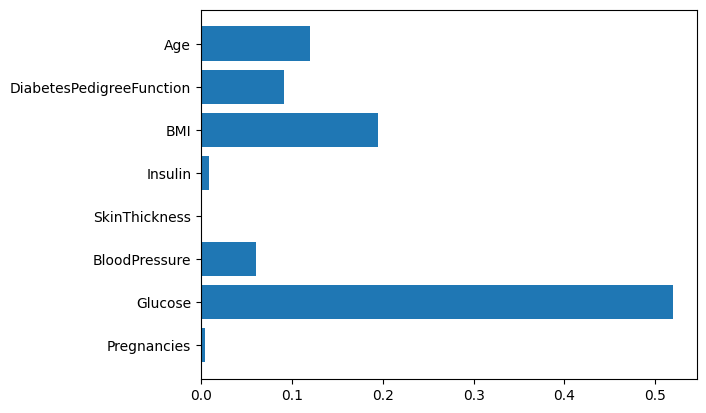

In [25]:
feature_importances = clftree4.feature_importances_
plt.barh(X.columns, feature_importances)
plt.show()